**Dataset Source:** [IMDb Top 5000 Movies — Kaggle](https://www.kaggle.com/datasets/tiagoadrianunes/imdb-top-5000-movies/data)  
**Financial Data:** TMDB API via `tmdb_api.py`

# P1 — Problem & EDA: IMDb Top 5000 Movies
**Course:** YZM2011 — Introduction to Machine Learning

# 1. Problem Formulation

## Research Question
What factors drive the financial success and audience reception of movies in the IMDb Top 5000?

## Motivation
The film industry spends billions of dollars each year on productions with highly uncertain returns. Understanding what separates a high-rated or high-grossing film from an average one has real commercial value — for studios deciding where to invest, for streaming platforms predicting catalog value, and for researchers studying cultural trends.

## Dataset
We combine two sources:
- **IMDb Top 5000** (via Kaggle): ranking, rating, votes, runtime, genres, directors, writers, release year.
- **TMDB API**: production budget and box-office revenue for each film.

## Key Questions We Will Explore
1. How are ratings and financial metrics distributed across the dataset?
2. Which genres and directors dominate in terms of revenue and rating?
3. How have movie budgets, runtimes, and ratings changed over time?
4. Are budget, revenue, runtime, and release year statistically correlated with IMDb rating?

## Scope of This Deliverable (P1)
This notebook covers data collection, cleaning, feature engineering, exploratory data analysis, and hypothesis testing. Regression modelling (P2) and classification modelling (P3) are addressed in separate notebooks.

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# 2. Data Collection and Cleaning

In [96]:
# Load the IMDb dataset (top 5000 movies with crew info)
imdb_data = pd.read_csv("results_with_crew.csv")
imdb_data

,tconst,primaryTitle,startYear,rank,averageRating,numVotes,runtimeMinutes,directors,writers,genres,IMDbLink,Title_IMDb_Link
0,tt0111161,The Shawshank Redemption,1994,1,9.3,3035155,142,Frank Darabont,"Stephen King, Frank Darabont",Drama,"<a href=""https://www.imdb.com/title/tt0111161""...","<a href=""https://www.imdb.com/title/tt0111161""..."
1,tt0068646,The Godfather,1972,2,9.2,2118800,175,Francis Ford Coppola,"Mario Puzo, Francis Ford Coppola","Crime, Drama","<a href=""https://www.imdb.com/title/tt0068646""...","<a href=""https://www.imdb.com/title/tt0068646""..."
2,tt0468569,The Dark Knight,2008,3,9.0,3011856,152,Christopher Nolan,"Jonathan Nolan, Christopher Nolan, David S. Go...","Action, Crime, Drama","<a href=""https://www.imdb.com/title/tt0468569""...","<a href=""https://www.imdb.com/title/tt0468569""..."
3,tt0167260,The Lord of the Rings: The Return of the King,2003,4,9.0,2072483,201,Peter Jackson,"J.R.R. Tolkien, Fran Walsh, Philippa Boyens, P...","Adventure, Drama, Fantasy","<a href=""https://www.imdb.com/title/tt0167260""...","<a href=""https://www.imdb.com/title/tt0167260""..."
4,tt0108052,Schindler's List,1993,5,9.0,1518412,195,Steven Spielberg,"Thomas Keneally, Steven Zaillian","Biography, Drama, History","<a href=""https://www.imdb.com/title/tt0108052""...","<a href=""https://www.imdb.com/title/tt0108052""..."
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,tt0116287,Fear,1996,4996,6.2,58507,97,James Foley,Christopher Crowe,"Drama, Thriller","<a href=""https://www.imdb.com/title/tt0116287""...","<a href=""https://www.imdb.com/title/tt0116287""..."
4996,tt0109068,Airheads,1994,4997,6.2,58037,92,Michael Lehmann,Rich Wilkes,"Comedy, Crime, Music","<a href=""https://www.imdb.com/title/tt0109068""...","<a href=""https://www.imdb.com/title/tt0109068""..."
4997,tt0109190,Baby's Day Out,1994,4998,6.2,58024,99,Patrick Read Johnson,John Hughes,"Adventure, Comedy, Crime","<a href=""https://www.imdb.com/title/tt0109190""...","<a href=""https://www.imdb.com/title/tt0109190""..."
4998,tt0947802,Lakeview Terrace,2008,4999,6.2,57709,110,Neil LaBute,"David Loughery, Howard Korder","Crime, Drama, Thriller","<a href=""https://www.imdb.com/title/tt0947802""...","<a href=""https://www.imdb.com/title/tt0947802""..."


In [97]:
# Load the TMDB budget/revenue data collected via tmdb_api.py
budget_revenue = pd.read_csv("budget_revenue.csv")
budget_revenue

,imdb_title,tmdb_titles,budget,revenue
0,The Shawshank Redemption,The Shawshank Redemption,25000000.0,2.834147e+07
1,The Godfather,The Godfather,6000000.0,2.450664e+08
2,The Dark Knight,The Dark Knight,185000000.0,1.004558e+09
3,The Lord of the Rings: The Return of the King,The Lord of the Rings: The Return of the King,94000000.0,1.118889e+09
4,Schindler's List,Schindler's List,22000000.0,3.213656e+08
...,...,...,...,...
4995,Fear,Fear,0.0,2.100000e+06
4996,Airheads,Airheads,15000000.0,5.751882e+06
4997,Baby's Day Out,Baby's Day Out,50000000.0,1.667150e+07
4998,Lakeview Terrace,Lakeview Terrace,20000000.0,2.764003e+07


## 2.1 Merging IMDb and TMDB Data
The `budget_revenue` table was generated row-by-row from the TMDB API using the same movie order as `imdb_data`, so we can join them by position.

In [98]:
# Deep copy of imdb_data so we don't mutate the original
data = imdb_data.copy()
# Append TMDB columns
data[["tmdb_titles", "budget", "revenues"]] = budget_revenue[["tmdb_titles", "budget", "revenue"]]
data

,tconst,primaryTitle,startYear,rank,averageRating,numVotes,runtimeMinutes,directors,writers,genres,IMDbLink,Title_IMDb_Link,tmdb_titles,budget,revenues
0,tt0111161,The Shawshank Redemption,1994,1,9.3,3035155,142,Frank Darabont,"Stephen King, Frank Darabont",Drama,"<a href=""https://www.imdb.com/title/tt0111161""...","<a href=""https://www.imdb.com/title/tt0111161""...",The Shawshank Redemption,25000000.0,2.834147e+07
1,tt0068646,The Godfather,1972,2,9.2,2118800,175,Francis Ford Coppola,"Mario Puzo, Francis Ford Coppola","Crime, Drama","<a href=""https://www.imdb.com/title/tt0068646""...","<a href=""https://www.imdb.com/title/tt0068646""...",The Godfather,6000000.0,2.450664e+08
2,tt0468569,The Dark Knight,2008,3,9.0,3011856,152,Christopher Nolan,"Jonathan Nolan, Christopher Nolan, David S. Go...","Action, Crime, Drama","<a href=""https://www.imdb.com/title/tt0468569""...","<a href=""https://www.imdb.com/title/tt0468569""...",The Dark Knight,185000000.0,1.004558e+09
3,tt0167260,The Lord of the Rings: The Return of the King,2003,4,9.0,2072483,201,Peter Jackson,"J.R.R. Tolkien, Fran Walsh, Philippa Boyens, P...","Adventure, Drama, Fantasy","<a href=""https://www.imdb.com/title/tt0167260""...","<a href=""https://www.imdb.com/title/tt0167260""...",The Lord of the Rings: The Return of the King,94000000.0,1.118889e+09
4,tt0108052,Schindler's List,1993,5,9.0,1518412,195,Steven Spielberg,"Thomas Keneally, Steven Zaillian","Biography, Drama, History","<a href=""https://www.imdb.com/title/tt0108052""...","<a href=""https://www.imdb.com/title/tt0108052""...",Schindler's List,22000000.0,3.213656e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,tt0116287,Fear,1996,4996,6.2,58507,97,James Foley,Christopher Crowe,"Drama, Thriller","<a href=""https://www.imdb.com/title/tt0116287""...","<a href=""https://www.imdb.com/title/tt0116287""...",Fear,0.0,2.100000e+06
4996,tt0109068,Airheads,1994,4997,6.2,58037,92,Michael Lehmann,Rich Wilkes,"Comedy, Crime, Music","<a href=""https://www.imdb.com/title/tt0109068""...","<a href=""https://www.imdb.com/title/tt0109068""...",Airheads,15000000.0,5.751882e+06
4997,tt0109190,Baby's Day Out,1994,4998,6.2,58024,99,Patrick Read Johnson,John Hughes,"Adventure, Comedy, Crime","<a href=""https://www.imdb.com/title/tt0109190""...","<a href=""https://www.imdb.com/title/tt0109190""...",Baby's Day Out,50000000.0,1.667150e+07
4998,tt0947802,Lakeview Terrace,2008,4999,6.2,57709,110,Neil LaBute,"David Loughery, Howard Korder","Crime, Drama, Thriller","<a href=""https://www.imdb.com/title/tt0947802""...","<a href=""https://www.imdb.com/title/tt0947802""...",Lakeview Terrace,20000000.0,2.764003e+07


## 2.2 Basic Data Inspection

In [99]:
data.head()

,tconst,primaryTitle,startYear,rank,averageRating,numVotes,runtimeMinutes,directors,writers,genres,IMDbLink,Title_IMDb_Link,tmdb_titles,budget,revenues
0,tt0111161,The Shawshank Redemption,1994,1,9.3,3035155,142,Frank Darabont,"Stephen King, Frank Darabont",Drama,"<a href=""https://www.imdb.com/title/tt0111161""...","<a href=""https://www.imdb.com/title/tt0111161""...",The Shawshank Redemption,25000000.0,2.834147e+07
1,tt0068646,The Godfather,1972,2,9.2,2118800,175,Francis Ford Coppola,"Mario Puzo, Francis Ford Coppola","Crime, Drama","<a href=""https://www.imdb.com/title/tt0068646""...","<a href=""https://www.imdb.com/title/tt0068646""...",The Godfather,6000000.0,2.450664e+08
2,tt0468569,The Dark Knight,2008,3,9.0,3011856,152,Christopher Nolan,"Jonathan Nolan, Christopher Nolan, David S. Go...","Action, Crime, Drama","<a href=""https://www.imdb.com/title/tt0468569""...","<a href=""https://www.imdb.com/title/tt0468569""...",The Dark Knight,185000000.0,1.004558e+09
3,tt0167260,The Lord of the Rings: The Return of the King,2003,4,9.0,2072483,201,Peter Jackson,"J.R.R. Tolkien, Fran Walsh, Philippa Boyens, P...","Adventure, Drama, Fantasy","<a href=""https://www.imdb.com/title/tt0167260""...","<a href=""https://www.imdb.com/title/tt0167260""...",The Lord of the Rings: The Return of the King,94000000.0,1.118889e+09
4,tt0108052,Schindler's List,1993,5,9.0,1518412,195,Steven Spielberg,"Thomas Keneally, Steven Zaillian","Biography, Drama, History","<a href=""https://www.imdb.com/title/tt0108052""...","<a href=""https://www.imdb.com/title/tt0108052""...",Schindler's List,22000000.0,3.213656e+08


In [100]:
data.tail()

,tconst,primaryTitle,startYear,rank,averageRating,numVotes,runtimeMinutes,directors,writers,genres,IMDbLink,Title_IMDb_Link,tmdb_titles,budget,revenues
4995,tt0116287,Fear,1996,4996,6.2,58507,97,James Foley,Christopher Crowe,"Drama, Thriller","<a href=""https://www.imdb.com/title/tt0116287""...","<a href=""https://www.imdb.com/title/tt0116287""...",Fear,0.0,2100000.0
4996,tt0109068,Airheads,1994,4997,6.2,58037,92,Michael Lehmann,Rich Wilkes,"Comedy, Crime, Music","<a href=""https://www.imdb.com/title/tt0109068""...","<a href=""https://www.imdb.com/title/tt0109068""...",Airheads,15000000.0,5751882.0
4997,tt0109190,Baby's Day Out,1994,4998,6.2,58024,99,Patrick Read Johnson,John Hughes,"Adventure, Comedy, Crime","<a href=""https://www.imdb.com/title/tt0109190""...","<a href=""https://www.imdb.com/title/tt0109190""...",Baby's Day Out,50000000.0,16671505.0
4998,tt0947802,Lakeview Terrace,2008,4999,6.2,57709,110,Neil LaBute,"David Loughery, Howard Korder","Crime, Drama, Thriller","<a href=""https://www.imdb.com/title/tt0947802""...","<a href=""https://www.imdb.com/title/tt0947802""...",Lakeview Terrace,20000000.0,27640028.0
4999,tt0109635,Disclosure,1994,5000,6.2,56351,128,Barry Levinson,"Michael Crichton, Paul Attanasio","Drama, Thriller","<a href=""https://www.imdb.com/title/tt0109635""...","<a href=""https://www.imdb.com/title/tt0109635""...",Disclosure,55000000.0,214015089.0


In [101]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           5000 non-null   str    
 1   primaryTitle     5000 non-null   str    
 2   startYear        5000 non-null   int64  
 3   rank             5000 non-null   int64  
 4   averageRating    5000 non-null   float64
 5   numVotes         5000 non-null   int64  
 6   runtimeMinutes   5000 non-null   int64  
 7   directors        5000 non-null   str    
 8   writers          4974 non-null   str    
 9   genres           5000 non-null   str    
 10  IMDbLink         5000 non-null   str    
 11  Title_IMDb_Link  5000 non-null   str    
 12  tmdb_titles      4999 non-null   str    
 13  budget           4999 non-null   float64
 14  revenues         4999 non-null   float64
dtypes: float64(3), int64(4), str(8)
memory usage: 586.1 KB


In [102]:
data.describe().map("{:.2f}".format)

,startYear,rank,averageRating,numVotes,runtimeMinutes,budget,revenues
count,5000.00,5000.00,5000.00,5000.00,5000.00,4999.00,4999.00
mean,2002.02,2500.50,7.14,163295.44,114.57,26279932.19,91634309.71
std,18.27,1443.52,0.60,240859.84,23.23,42847118.33,197216176.75
min,1915.00,1.00,5.90,25004.00,25.00,0.00,0.00
25%,1994.00,1250.75,6.70,40078.75,99.00,3411.50,540900.00
50%,2007.00,2500.50,7.10,74546.50,111.00,10000000.00,20205757.00
75%,2015.00,3750.25,7.60,178531.25,126.00,30000000.00,87623759.00
max,2025.00,5000.00,9.30,3035155.00,374.00,460000000.00,2923706026.00


In [103]:
print("Shape:", data.shape)

Shape: (5000, 15)


## 2.3 Missing Value Handling

In [104]:
data.isnull().sum()

tconst              0
primaryTitle        0
startYear           0
rank                0
averageRating       0
numVotes            0
runtimeMinutes      0
directors           0
writers            26
genres              0
IMDbLink            0
Title_IMDb_Link     0
tmdb_titles         1
budget              1
revenues            1
dtype: int64

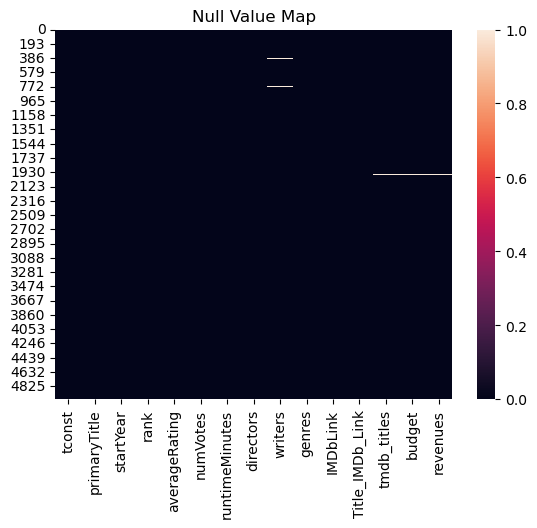

In [105]:
# Visualise which rows/columns contain null values
sns.heatmap(data.isnull())
plt.title("Null Value Map")
plt.show()

In [106]:
# The 26 null writers are all documentaries where the director is typically the sole author.
# We assign by title name (not by list position) so the mapping is safe even if the
# DataFrame is sorted or reindexed before this cell runs.
writer_corrections = {
    "David Attenborough: A Life on Our Planet": "David Attenborough",
    "Free Solo":                                "Jimmy Chin, Elizabeth Chai Vasarhelyi",
    "Citizenfour":                              "Laura Poitras",
    "What Is a Woman?":                         "Justin Folk",
    "The Act of Killing":                       "Joshua Oppenheimer, Christine Cynn",
    "They Shall Not Grow Old":                  "Peter Jackson",
    "Hoop Dreams":                              "Steve James",
    "Won't You Be My Neighbor?":                "Fred Rogers, Kevin Van Sant",
    "Exit Through the Gift Shop":               "Banksy, Jaimie D'Cruz",
    "Seaspiracy":                               "Ali Tabrizi",
    "Apollo 11":                                "Mark Monroe",
    "Amy":                                      "Asif Kapadia",
    "Jiro Dreams of Sushi":                     "David Gelb",
    "Black Hawk Down":                          "Ridley Scott, Robert David Port",
    "Jodorowsky's Dune":                        "Frank Pavich",
    "The Fog of War":                           "Errol Morris",
    "Navalny":                                  "Daniel Roher",
    "Jim & Andy: The Great Beyond":             "Chris Smith",
    "Capturing the Friedmans":                  "Alex Gibney",
    "The Imposter":                             "Andy Grieve",
    "Jesus Camp":                               "Heidi Ewing, Enat Sidi, Rachel Grady",
    "Miss Americana":                           "Jenner Furst, Julia Willoughby Nason",
    "Fyre":                                     "Kirby Dick, Amy Ziering",
    "This Is It":                               "Kenny Ortega, Michael Jackson",
    "American Murder: The Family Next Door":     "Rudy Valdez",
    "Catfish":                                  "Henry Joost, Ariel Schulman",
}

for title, writer in writer_corrections.items():
    data.loc[data["primaryTitle"] == title, "writers"] = writer

# Verify all nulls are resolved
remaining = data["writers"].isnull().sum()
print(f"Remaining null writers: {remaining}")
if remaining > 0:
    print("Titles still missing writers:")
    print(data.loc[data["writers"].isnull(), "primaryTitle"].tolist())

Remaining null writers: 0


One movie — *Yahşi Batı (The Ottoman Cowboys)* — failed to return data from the TMDB API during collection. We fill it manually using its known production figures.

In [107]:
data.loc[data["primaryTitle"] == "Yahsi Bati - The Ottoman Cowboys",
         ["tmdb_titles", "budget", "revenues"]] = ["Yahşi Batı", 2000000, 13565059]

print("Remaining nulls:", data.isnull().sum().sum())

Remaining nulls: 0


## 2.4 Duplicate Check

In [108]:
print("Any duplicates:", data.duplicated().any())

Any duplicates: False


## 2.5 Correcting Title Mismatches (`diff_fix`)
A subset of titles returned different TMDB matches because of localised titles, remasters, or ambiguous search results. These records were manually checked, and the corrected TMDB titles and financial values are stored in `diff_fix.csv`.


In [109]:
diff_fix = pd.read_csv("diff_fix.csv")

# Apply manually verified TMDB corrections before any financial imputation.
for _, row in diff_fix.iterrows():
    imdb_title = row["imdb_title"]
    data.loc[data["primaryTitle"] == imdb_title,
             ["tmdb_titles", "budget", "revenues"]] = [row["tmdb_title"], row["budget"], row["revenue"]]

print(f"Applied corrections for {len(diff_fix)} titles.")
print(f"Movies with zero budget before final cleanup:  {(data['budget'] == 0).sum()}")
print(f"Movies with zero revenue before final cleanup: {(data['revenues'] == 0).sum()}")


Applied corrections for 152 titles.
Movies with zero budget before final cleanup:  1231
Movies with zero revenue before final cleanup: 1075


## 2.6 Handling Zero Values in Budget and Revenue
Many TMDB responses still report `0` for budget or revenue even after title corrections. For financial EDA, we treat those zeros as missing values and replace them with the **median of the non-zero values**. Median imputation is more defensible than mean imputation here because both distributions are heavily right-skewed.


In [110]:
budget_zero_mask = data["budget"].eq(0)
revenue_zero_mask = data["revenues"].eq(0)

budget_zero_count = budget_zero_mask.sum()
revenue_zero_count = revenue_zero_mask.sum()

nonzero_budget_median = data.loc[~budget_zero_mask, "budget"].median()
nonzero_revenue_median = data.loc[~revenue_zero_mask, "revenues"].median()

data.loc[budget_zero_mask, "budget"] = nonzero_budget_median
data.loc[revenue_zero_mask, "revenues"] = nonzero_revenue_median

print(f"Movies imputed in budget:  {budget_zero_count}")
print(f"Movies imputed in revenue: {revenue_zero_count}")
print(f"Median budget used for imputation:  ${nonzero_budget_median:,.0f}")
print(f"Median revenue used for imputation: ${nonzero_revenue_median:,.0f}")
print(f"Remaining zero budgets:  {(data['budget'] == 0).sum()}")
print(f"Remaining zero revenues: {(data['revenues'] == 0).sum()}")


Movies imputed in budget:  1231
Movies imputed in revenue: 1075
Median budget used for imputation:  $18,500,000
Median revenue used for imputation: $39,000,000
Remaining zero budgets:  0
Remaining zero revenues: 0


# 3. Feature Engineering

We derive four new columns to support financial and classification analyses:

| Feature | Definition | Type |
|---------|-----------|------|
| `profit` | revenue − budget | Continuous |
| `roi` | profit / budget | Continuous |
| `good_or_avg` | 1 if rating ≥ 7.5, else 0 | Binary |
| `popularity` | 0/1/2 based on vote-count percentiles (60th, 90th) | Ordinal |

In [111]:
# Financial metrics
data["profit"] = data["revenues"] - data["budget"]
data["roi"]    = data["profit"] / data["budget"]

In [112]:
# Binary quality label: 1 = good (rating >= 7.5), 0 = average
data["good_or_avg"] = (data["averageRating"] >= 7.5).astype(int)
print("Class distribution for good_or_avg:")
print(data["good_or_avg"].value_counts())

Class distribution for good_or_avg:
good_or_avg
0    3448
1    1552
Name: count, dtype: int64


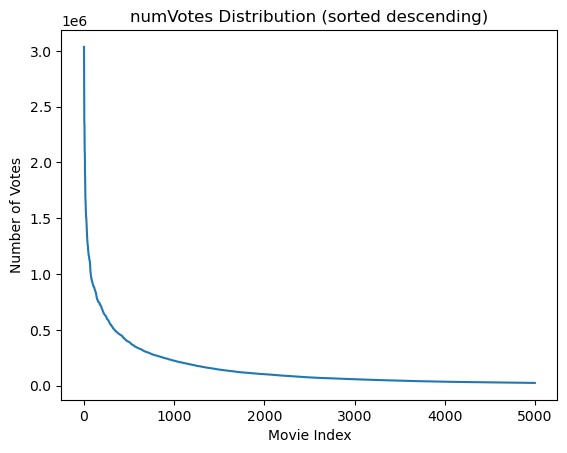

In [113]:
# Visualise vote distribution to justify threshold choice
sns.lineplot(data=data.sort_values(by="numVotes", ascending=False),
             y="numVotes", x=data.index)
plt.title("numVotes Distribution (sorted descending)")
plt.xlabel("Movie Index")
plt.ylabel("Number of Votes")
plt.show()

In [114]:
# 3-level popularity: 0=low, 1=moderate, 2=high
# Thresholds chosen at the 60th and 90th percentiles — natural break points in the distribution above.
p60 = data["numVotes"].quantile(0.60)
p90 = data["numVotes"].quantile(0.90)
print(f"60th percentile: {p60:,.0f}  |  90th percentile: {p90:,.0f}")

data["popularity"] = 0
data.loc[(data["numVotes"] >= p60) & (data["numVotes"] < p90), "popularity"] = 1
data.loc[data["numVotes"] >= p90, "popularity"] = 2

print("\nPopularity class distribution:")
print(data["popularity"].value_counts().sort_index())

60th percentile: 103,308  |  90th percentile: 392,651

Popularity class distribution:
popularity
0    3000
1    1500
2     500
Name: count, dtype: int64


In [115]:
# Final cleaned dataset overview
data.columns.tolist()

['tconst',
 'primaryTitle',
 'startYear',
 'rank',
 'averageRating',
 'numVotes',
 'runtimeMinutes',
 'directors',
 'writers',
 'genres',
 'IMDbLink',
 'Title_IMDb_Link',
 'tmdb_titles',
 'budget',
 'revenues',
 'profit',
 'roi',
 'good_or_avg',
 'popularity']

# 4. Exploratory Data Analysis

## 4.1 Univariate Analysis

### Top 10 Movies by Rating

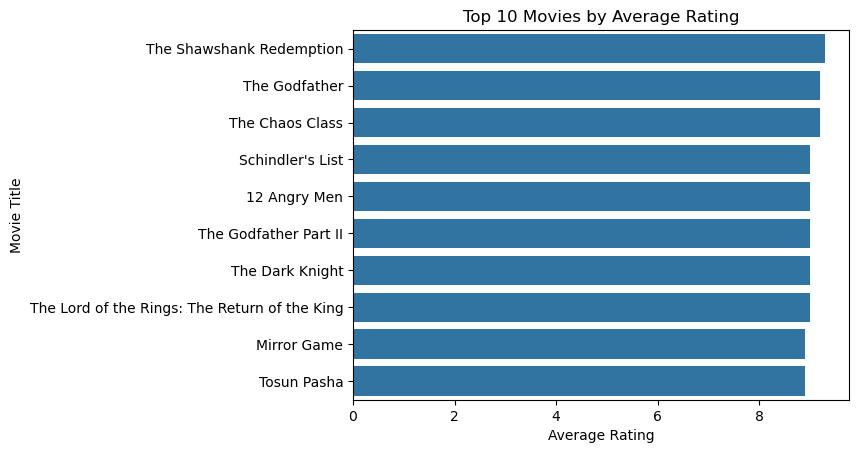

In [116]:
top_10_rating = data.sort_values(by="averageRating", ascending=False).head(10)
sns.barplot(y="primaryTitle", x="averageRating", data=top_10_rating)
plt.title("Top 10 Movies by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Movie Title")
plt.show()

### Top 10 Movies by Budget

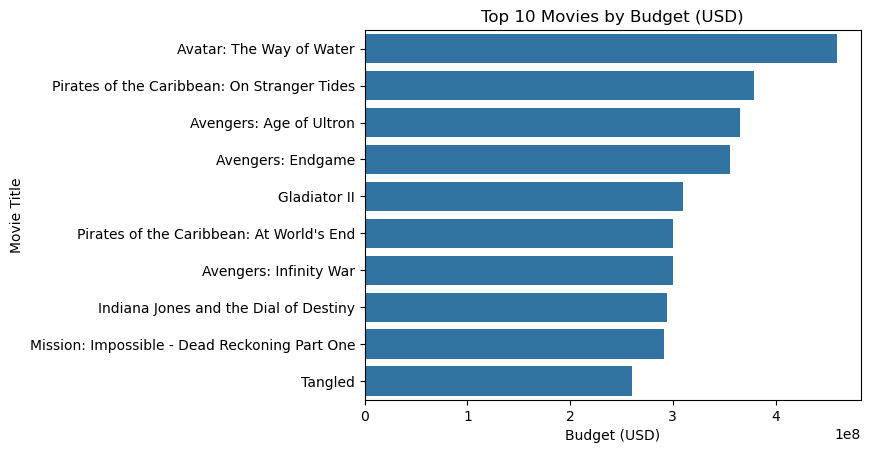

In [117]:
top_10_budget = data.sort_values(by="budget", ascending=False).head(10)
sns.barplot(y="primaryTitle", x="budget", data=top_10_budget)
plt.title("Top 10 Movies by Budget (USD)")
plt.xlabel("Budget (USD)")
plt.ylabel("Movie Title")
plt.show()

### Top 10 Movies by Revenue

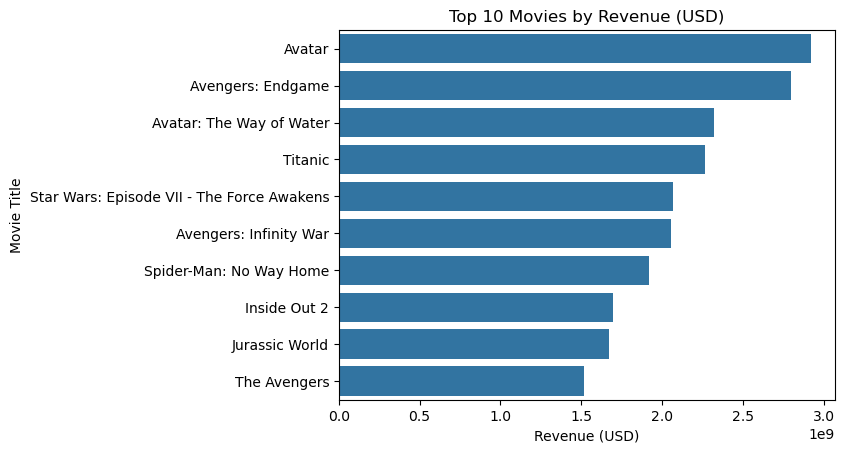

In [118]:
top_10_revenue = data.sort_values(by="revenues", ascending=False).head(10)
sns.barplot(y="primaryTitle", x="revenues", data=top_10_revenue)
plt.title("Top 10 Movies by Revenue (USD)")
plt.xlabel("Revenue (USD)")
plt.ylabel("Movie Title")
plt.show()

### Top 10 Longest Movies by Runtime

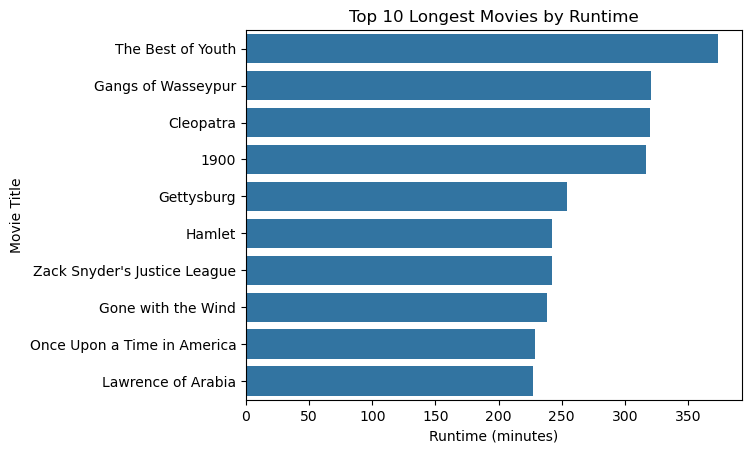

In [119]:
top_10_longest = data.sort_values(by="runtimeMinutes", ascending=False).head(10)
sns.barplot(y="primaryTitle", x="runtimeMinutes", data=top_10_longest)
plt.title("Top 10 Longest Movies by Runtime")
plt.xlabel("Runtime (minutes)")
plt.ylabel("Movie Title")
plt.show()

### Distribution of Movies by Release Year

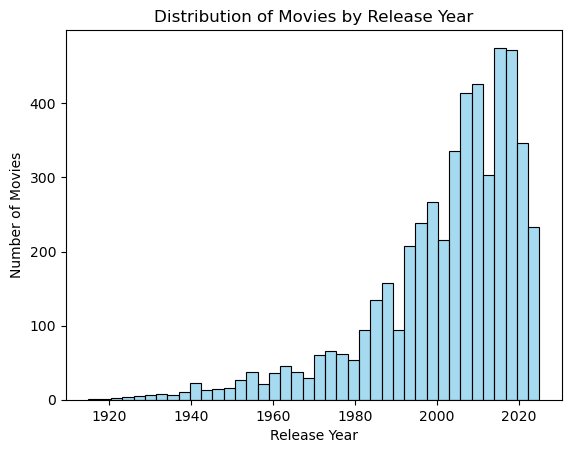

In [120]:
sns.histplot(data=data, x="startYear", bins=40, kde=False, color="skyblue")
plt.title("Distribution of Movies by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Movies")
plt.show()

### Distribution of IMDb Ratings

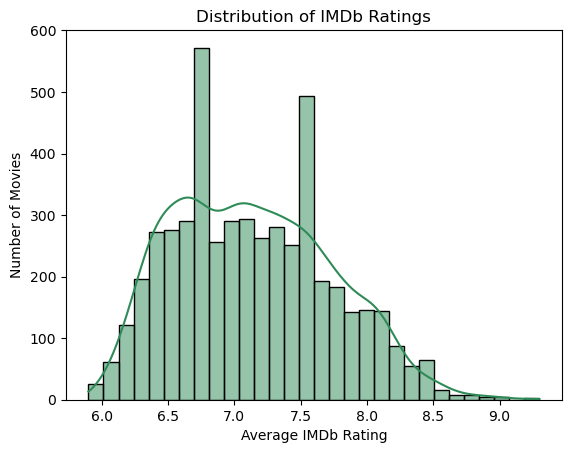

In [121]:
sns.histplot(data=data, x="averageRating", bins=30, kde=True, color="seagreen")
plt.title("Distribution of IMDb Ratings")
plt.xlabel("Average IMDb Rating")
plt.ylabel("Number of Movies")
plt.show()

### Distribution of Movie Budgets

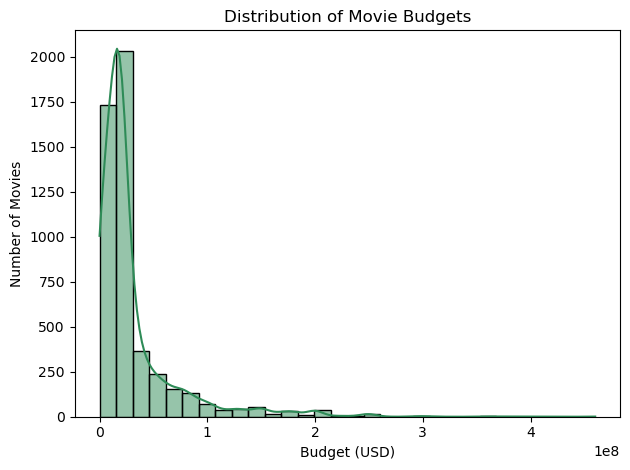

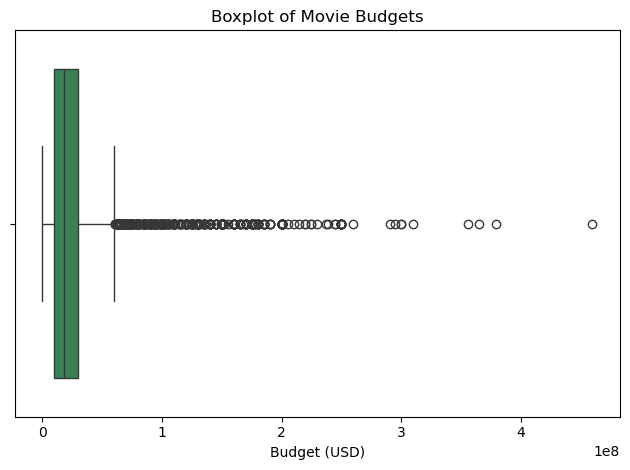

In [122]:
sns.histplot(data=data, x="budget", bins=30, kde=True, color="seagreen")
plt.title("Distribution of Movie Budgets")
plt.xlabel("Budget (USD)")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.show()

sns.boxplot(data=data, x="budget", color="seagreen")
plt.title("Boxplot of Movie Budgets")
plt.xlabel("Budget (USD)")
plt.tight_layout()
plt.show()

### Outlier Analysis
The boxplot above shows a heavily right-skewed budget distribution with extreme outliers. Let's quantify these.

In [123]:
# IQR-based outlier detection for budget and revenue
for col in ["budget", "revenues", "profit"]:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_fence = Q3 + 1.5 * IQR
    outliers = data[data[col] > upper_fence]
    print(f"{col}: {len(outliers)} outliers above ${upper_fence:,.0f}")

budget: 636 outliers above $60,000,000
revenues: 647 outliers above $195,728,587
profit: 691 outliers above $135,560,618


In [124]:
# Top 5 budget outliers
print("Top 5 highest-budget films:")
data.sort_values("budget", ascending=False)[["primaryTitle", "startYear", "budget", "revenues", "profit"]].head()

Top 5 highest-budget films:


,primaryTitle,startYear,budget,revenues,profit
1072,Avatar: The Way of Water,2022,460000000.0,2.320250e+09,1.860250e+09
4366,Pirates of the Caribbean: On Stranger Tides,2011,379000000.0,1.046721e+09,6.677213e+08
1673,Avengers: Age of Ultron,2015,365000000.0,1.405404e+09,1.040404e+09
54,Avengers: Endgame,2019,356000000.0,2.799439e+09,2.443439e+09
4416,Gladiator II,2024,310000000.0,4.621807e+08,1.521807e+08


In [125]:
# Top 5 revenue outliers
print("Top 5 highest-revenue films:")
data.sort_values("revenues", ascending=False)[["primaryTitle", "startYear", "budget", "revenues", "profit"]].head()

Top 5 highest-revenue films:


,primaryTitle,startYear,budget,revenues,profit
310,Avatar,2009,237000000.0,2.923706e+09,2.686706e+09
54,Avengers: Endgame,2019,356000000.0,2.799439e+09,2.443439e+09
1072,Avatar: The Way of Water,2022,460000000.0,2.320250e+09,1.860250e+09
311,Titanic,1997,200000000.0,2.264162e+09,2.064162e+09
422,Star Wars: Episode VII - The Force Awakens,2015,245000000.0,2.068224e+09,1.823224e+09


**Finding:** Budget and revenue distributions are highly right-skewed. A small number of blockbuster productions (e.g. *Avengers: Endgame*, *Pirates of the Caribbean*) pull the mean significantly above the median. These outliers are real data points, not errors, so we retain them — but regression models will need to account for this skew (e.g. log-transformations in P2).

## 4.2 Bivariate Analysis

### Top 10 Directors by Total Revenue

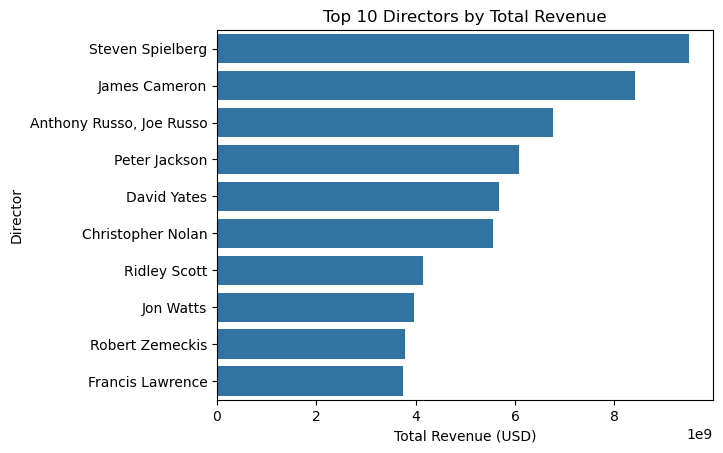

In [126]:
top_10_dir = (data.groupby("directors")["revenues"].sum()
              .sort_values(ascending=False).reset_index().head(10))

sns.barplot(y="directors", x="revenues", data=top_10_dir)
plt.title("Top 10 Directors by Total Revenue")
plt.xlabel("Total Revenue (USD)")
plt.ylabel("Director")
plt.show()

### Budget vs. Revenue

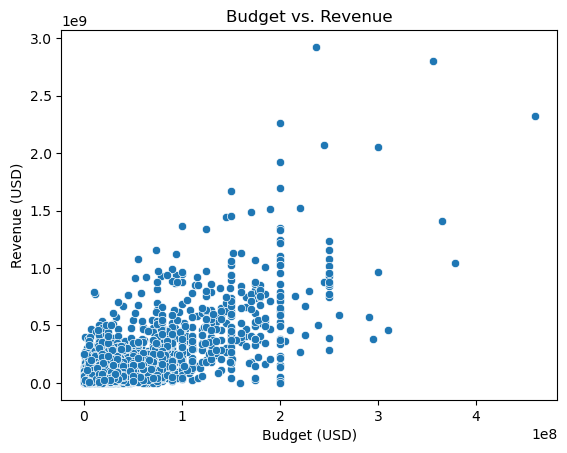

In [127]:
sns.scatterplot(data=data, x="budget", y="revenues")
plt.title("Budget vs. Revenue")
plt.xlabel("Budget (USD)")
plt.ylabel("Revenue (USD)")
plt.show()

### Rating vs. ROI

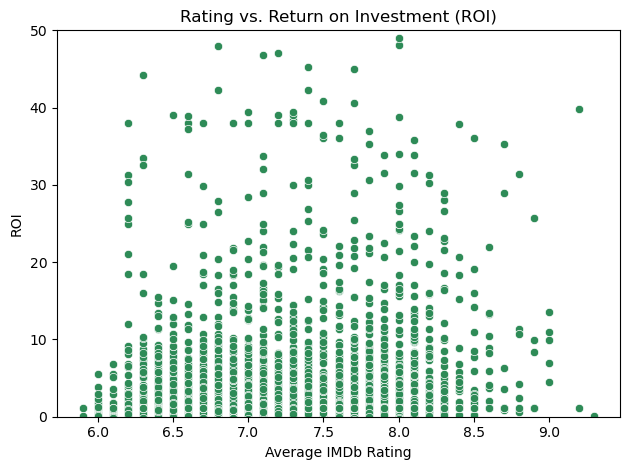

In [128]:
sns.scatterplot(data=data, x="averageRating", y="roi", color="seagreen")
plt.title("Rating vs. Return on Investment (ROI)")
plt.xlabel("Average IMDb Rating")
plt.ylabel("ROI")
plt.ylim(0, 50)
plt.tight_layout()
plt.show()

### Rating vs. Profit

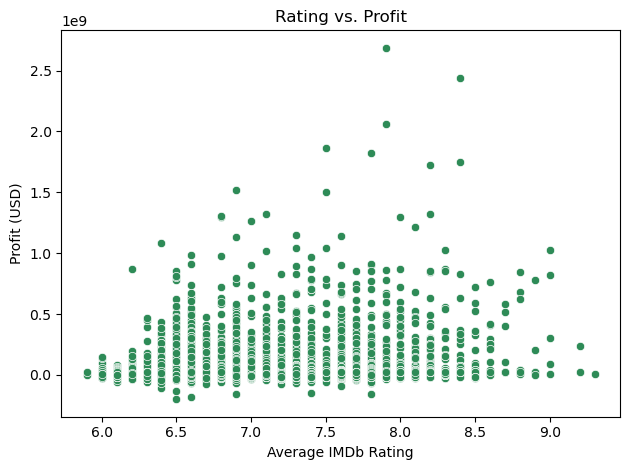

In [129]:
sns.scatterplot(data=data, x="averageRating", y="profit", color="seagreen")
plt.title("Rating vs. Profit")
plt.xlabel("Average IMDb Rating")
plt.ylabel("Profit (USD)")
plt.tight_layout()
plt.show()

### Runtime vs. Profit

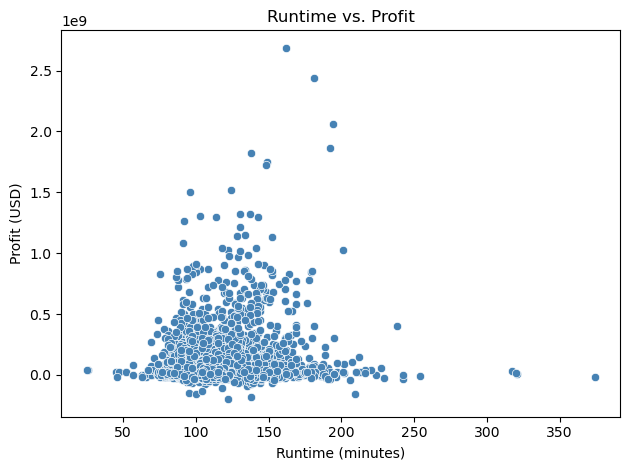

In [130]:
sns.scatterplot(data=data, x="runtimeMinutes", y="profit", color="steelblue")
plt.title("Runtime vs. Profit")
plt.xlabel("Runtime (minutes)")
plt.ylabel("Profit (USD)")
plt.tight_layout()
plt.show()

### Correlation Heatmap

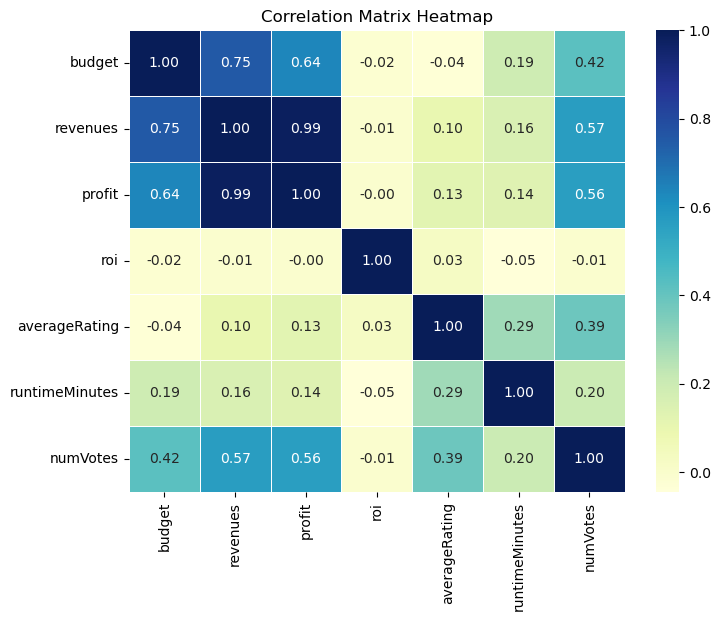

In [131]:
numeric_cols = data[["budget", "revenues", "profit", "roi",
                     "averageRating", "runtimeMinutes", "numVotes"]]
corr = numeric_cols.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()

## 4.3 Genre Analysis
The `genres` column contains comma-separated values. We explode it so each genre appears as a separate row, then analyse frequency, revenue, and rating by genre.

/tmp/ipykernel_48253/1356203780.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_counts.head(15), x="genre", y="count", palette="viridis")


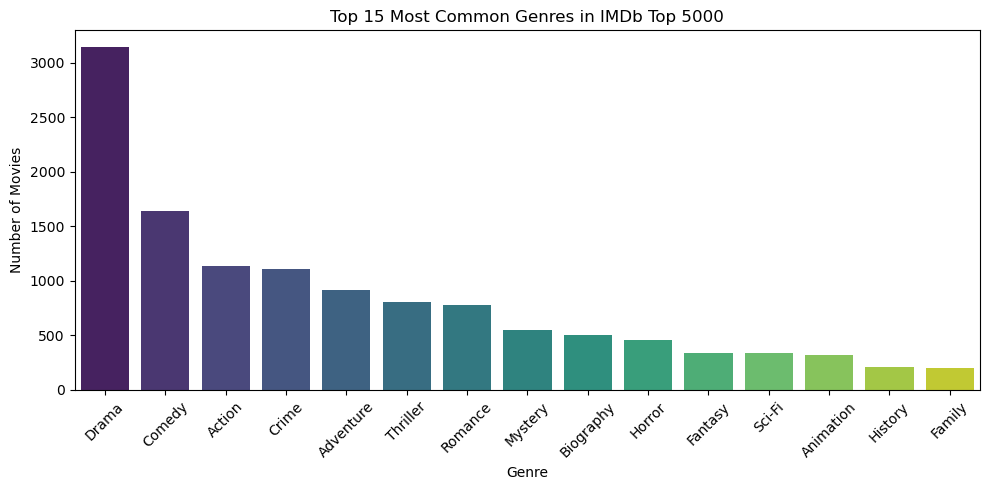

In [132]:
# Explode genres into one row per genre
genres_exploded = data.copy()
genres_exploded["genre"] = genres_exploded["genres"].str.split(r",\s*")
genres_exploded = genres_exploded.explode("genre")

# Genre frequency
genre_counts = genres_exploded["genre"].value_counts().reset_index()
genre_counts.columns = ["genre", "count"]

plt.figure(figsize=(10, 5))
sns.barplot(data=genre_counts.head(15), x="genre", y="count", palette="viridis")
plt.title("Top 15 Most Common Genres in IMDb Top 5000")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_48253/298388518.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_revenue, x="genre", y="revenues", palette="coolwarm")


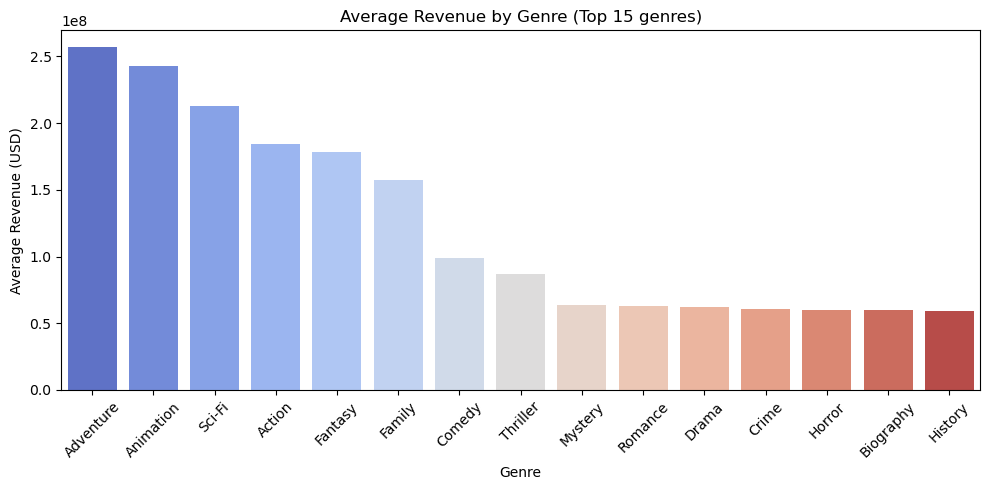

In [133]:
# Average revenue by genre (top 15 genres by frequency)
top_genres = genre_counts.head(15)["genre"].tolist()
genre_revenue = (genres_exploded[genres_exploded["genre"].isin(top_genres)]
                 .groupby("genre")["revenues"]
                 .mean()
                 .sort_values(ascending=False)
                 .reset_index())

plt.figure(figsize=(10, 5))
sns.barplot(data=genre_revenue, x="genre", y="revenues", palette="coolwarm")
plt.title("Average Revenue by Genre (Top 15 genres)")
plt.xlabel("Genre")
plt.ylabel("Average Revenue (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_48253/2544315150.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_rating, x="genre", y="averageRating", palette="mako")


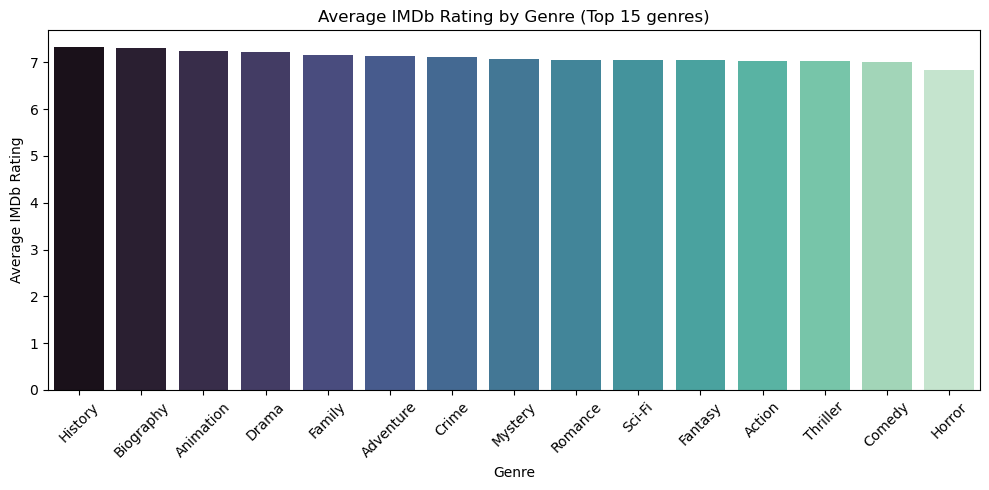

In [134]:
# Average IMDb rating by genre
genre_rating = (genres_exploded[genres_exploded["genre"].isin(top_genres)]
                .groupby("genre")["averageRating"]
                .mean()
                .sort_values(ascending=False)
                .reset_index())

plt.figure(figsize=(10, 5))
sns.barplot(data=genre_rating, x="genre", y="averageRating", palette="mako")
plt.title("Average IMDb Rating by Genre (Top 15 genres)")
plt.xlabel("Genre")
plt.ylabel("Average IMDb Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4.4 Temporal Analysis
We group movies by decade to examine how the industry has changed over time.

In [135]:
# Create a decade column
data["decade"] = (data["startYear"] // 10) * 10

decade_stats = data.groupby("decade").agg(
    movie_count=("primaryTitle", "count"),
    avg_rating=("averageRating", "mean"),
    avg_budget=("budget", "mean"),
    avg_revenue=("revenues", "mean"),
    avg_runtime=("runtimeMinutes", "mean")
).reset_index()

decade_stats

,decade,movie_count,avg_rating,avg_budget,avg_revenue,avg_runtime
0,1910,1,6.100000,8.500000e+06,1.586157e+07,195.000000
1,1920,12,8.100000,1.981025e+07,2.924544e+07,84.500000
2,1930,30,7.863333,1.185702e+07,5.917181e+07,100.533333
3,1940,58,7.836207,9.779267e+06,2.948541e+07,104.000000
4,1950,103,7.723301,1.464272e+07,4.632181e+07,109.912621
5,1960,138,7.676812,1.442745e+07,5.023378e+07,121.318841
6,1970,216,7.425463,9.877200e+06,5.886571e+07,115.032407
7,1980,412,7.143689,1.590549e+07,6.703074e+07,109.815534
8,1990,722,7.098199,2.860386e+07,9.405184e+07,114.126039
9,2000,1199,7.098249,3.475098e+07,1.035644e+08,113.914095


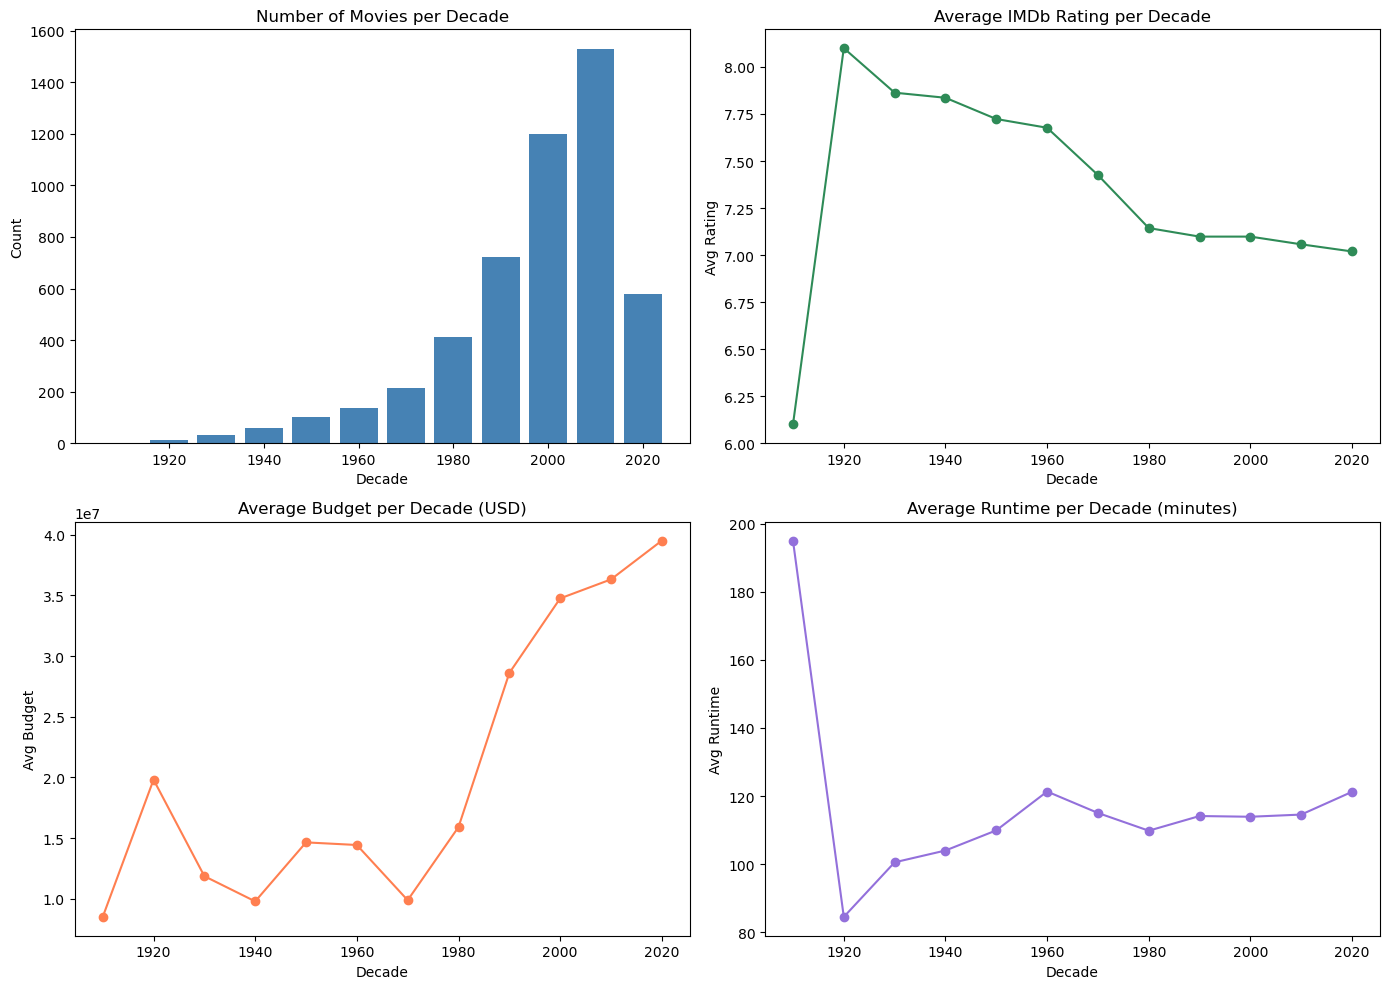

In [136]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Number of movies per decade
axes[0, 0].bar(decade_stats["decade"], decade_stats["movie_count"], color="steelblue", width=8)
axes[0, 0].set_title("Number of Movies per Decade")
axes[0, 0].set_xlabel("Decade")
axes[0, 0].set_ylabel("Count")

# Average rating per decade
axes[0, 1].plot(decade_stats["decade"], decade_stats["avg_rating"], marker="o", color="seagreen")
axes[0, 1].set_title("Average IMDb Rating per Decade")
axes[0, 1].set_xlabel("Decade")
axes[0, 1].set_ylabel("Avg Rating")

# Average budget per decade
axes[1, 0].plot(decade_stats["decade"], decade_stats["avg_budget"], marker="o", color="coral")
axes[1, 0].set_title("Average Budget per Decade (USD)")
axes[1, 0].set_xlabel("Decade")
axes[1, 0].set_ylabel("Avg Budget")

# Average runtime per decade
axes[1, 1].plot(decade_stats["decade"], decade_stats["avg_runtime"], marker="o", color="mediumpurple")
axes[1, 1].set_title("Average Runtime per Decade (minutes)")
axes[1, 1].set_xlabel("Decade")
axes[1, 1].set_ylabel("Avg Runtime")

plt.tight_layout()
plt.show()

# 5. Hypothesis Testing

We use the Pearson correlation coefficient to test linear relationships between numerical features. Significance level: α = 0.05.

### Hypothesis 1: Does Budget Affect IMDb Rating?
- **H₀:** Movie budget has no effect on IMDb rating.
- **Hₐ:** Movie budget has an effect on IMDb rating.

In [137]:
corr, p_val = pearsonr(data["budget"], data["averageRating"])
print(f"Pearson r: {corr:.3f}  |  p-value: {p_val:.4f}")

Pearson r: -0.037  |  p-value: 0.0098


**Result:** r = −0.037, p = 0.0098. Statistically significant but practically negligible — we reject H₀, but the effect size is too small to matter for decision-making.


### Hypothesis 2: Does Release Year Affect IMDb Rating?
- **H₀:** Release year has no effect on IMDb rating.
- **Hₐ:** Release year has an effect on IMDb rating.

In [138]:
corr, p_val = pearsonr(data["startYear"], data["averageRating"])
print(f"Pearson r: {corr:.3f}  |  p-value: {p_val:.4f}")

Pearson r: -0.274  |  p-value: 0.0000


**Result:** r = −0.274, p < 0.0001. Moderate negative correlation — newer movies in this top-5000 list tend to have slightly lower ratings, likely because recent films have had less time to accumulate votes from dedicated fans.

### Hypothesis 3: Is There a Correlation Between Revenue and IMDb Rating?
- **H₀:** No correlation between revenue and IMDb rating.
- **Hₐ:** There is a correlation between revenue and IMDb rating.

In [139]:
corr, p_val = pearsonr(data["revenues"], data["averageRating"])
print(f"Pearson r: {corr:.3f}  |  p-value: {p_val:.4f}")

Pearson r: 0.100  |  p-value: 0.0000


**Result:** r = 0.100, p < 0.0001. Statistically significant but weak. Higher-rated movies earn slightly more on average, but rating alone is still a poor predictor of revenue.


### Hypothesis 4: Is There a Correlation Between Budget and Profit?
- **H₀:** No correlation between budget and profit.
- **Hₐ:** There is a correlation between budget and profit.

In [140]:
corr, p_val = pearsonr(data["profit"], data["budget"])
print(f"Pearson r: {corr:.3f}  |  p-value: {p_val}")

Pearson r: 0.636  |  p-value: 0.0


**Result:** r = 0.636, p < 0.0001. Strong positive correlation — higher-budget films tend to generate higher profits in this dataset. This remains the clearest regression target for P2.


### Hypothesis 5: Does Runtime Affect IMDb Rating?
- **H₀:** No correlation between runtime and IMDb rating.
- **Hₐ:** There is a correlation between runtime and IMDb rating.

In [141]:
corr, p_val = pearsonr(data["runtimeMinutes"], data["averageRating"])
print(f"Pearson r: {corr:.3f}  |  p-value: {p_val:.4f}")

Pearson r: 0.287  |  p-value: 0.0000


**Result:** r = 0.287, p < 0.0001. Moderate positive correlation — longer movies tend to receive higher ratings, possibly because long runtimes are associated with epic or prestige films.

# 6. Conclusions

## Summary of Key Findings

### Data
- The merged dataset contains **5,000 movies** spanning 1915–2025.
- After applying manual TMDB corrections, zero placeholders in `budget` and `revenues` were treated as missing and imputed with **non-zero medians**, leaving no missing or zero-valued financial placeholders in the final EDA table.
- Budget and revenue remain **heavily right-skewed**: blockbuster films pull the mean well above the median, so robust summaries are more trustworthy than simple averages.
- About **69%** of movies fall into the `good_or_avg = 0` class, so the future classification task is moderately imbalanced.

### Genre
- **Drama** is the most common genre in the sample.
- Revenue is concentrated in blockbuster-oriented genres such as **Adventure** and **Action**, while highly rated genres such as **Documentary** and **Biography** tend to be less commercial.

### Temporal Trends
- The number of top-ranked films rises sharply from the 1990s onward.
- Average budgets increase over time, while average ratings trend slightly downward in this sample.

### Hypothesis Testing
| Hypothesis | r | Interpretation |
|---|---|---|
| Budget → Rating | −0.037 | Negligible |
| Year → Rating | −0.274 | Moderate negative |
| Revenue → Rating | 0.100 | Weak positive |
| Budget → Profit | 0.636 | Strong positive ✓ |
| Runtime → Rating | 0.287 | Moderate positive |

### P1 Takeaway
P1 establishes a cleaned, documented movie dataset and shows that **budget is the strongest linear signal for profit**, while rating-related relationships are much weaker. The main limitation is that financial data depends on TMDB matching and robust imputation for missing values, so P2 should keep outlier handling and feature transformations explicit when building regression models.
